# MACHINE LEARNING WITH PYTHON AND SCIKIT-LEARN

# LINEAR REGRESSION AND GRADIENT DESCENT

In [2]:
import pandas as pd

medical = pd.read_csv("./datasets/insurance.csv")
medical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
medical.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Exploratory analysis

In [5]:
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

In [72]:
sns.set_style("darkgrid")
matplotlib.rcParams["font.size"]=14
matplotlib.rcParams["figure.figsize"] = (10, 6)
matplotlib.rcParams["figure.facecolor"] = "#000000"

### Age

In [73]:
medical.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

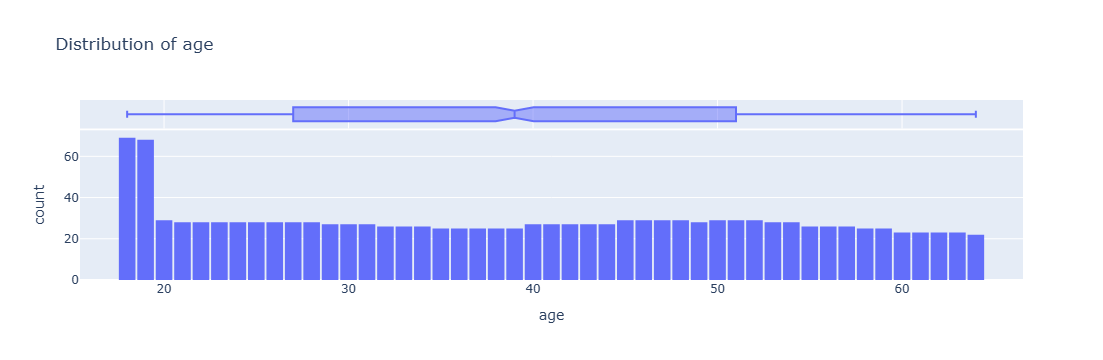

In [74]:
fig = px.histogram(medical,
                x="age",
                marginal="box",
                nbins=47,
                title="Distribution of age")
fig.update_layout(bargap=0.1)
fig.show()

This histogram  illustrates a uniform distribution except for the people who are 18 and 19 years old due to the fact the population in US among 18-69 is equally distributed. But for the insurance, we can see that the population who are 18 and 19 are twice more than the other, this might be because the insurance charge is lower when you are under 20 years old. Or also because, 18 is the legal age to subscribe to this insurance, so as soon as the people get 18 they subscribe to this insurance.

## Body Mass Index

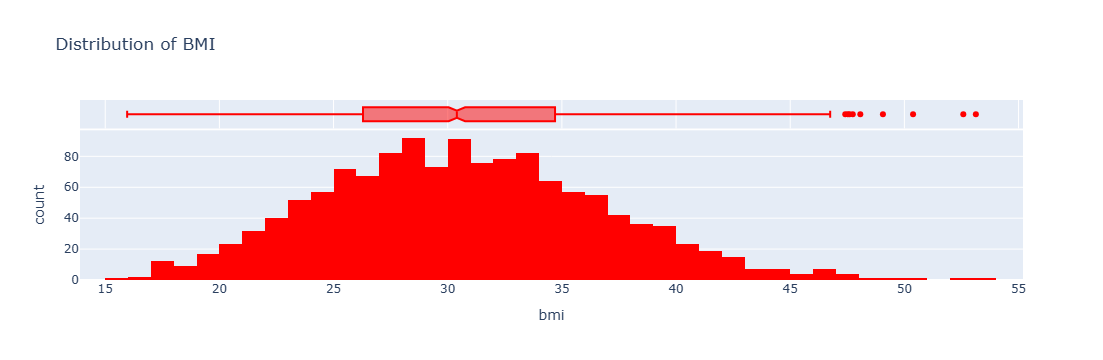

In [75]:
fig = px.histogram(medical,
                    x="bmi",
                    marginal="box",
                    nbins=47,
                   color_discrete_sequence = ["red"],
                    title= "Distribution of BMI")
fig.show()

The BMI plot illustrates a normal/gaussian(bell) distribution with a median bmi around 30.4, and 75% are around 26.29 and 34.7 (overweight), there are also some outliers above 47.41 (morbid obesity)

### Charges

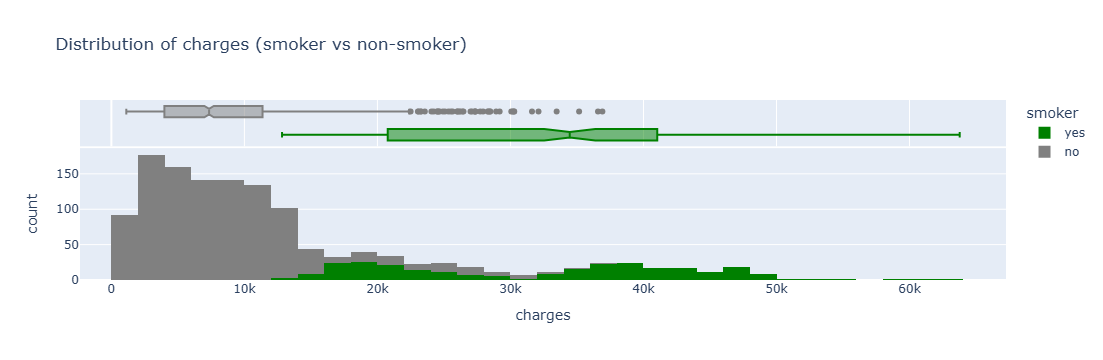

In [76]:
fig = px.histogram(
    medical,
    x="charges",
    marginal="box",
    color="smoker",
    color_discrete_sequence=["green", "gray"],
    title="Distribution of charges (smoker vs non-smoker)"
)

fig.show()

The distribution of charges is a right skewed distribution (mode< median< mean). We can see that non smokers pay less charges than other (75% of them are paying among 3985 and 11363 dollars, there are some outliers above 22.4k),on the other hand, smokers pay more charges than their mates (75% of them are paying among 20.77k and 41.03k for a median of 34.46k). There is a huge difference between smokers and non smokers in their annual charges (7345.4$ for non-smoker abd 34.4k for smokers)

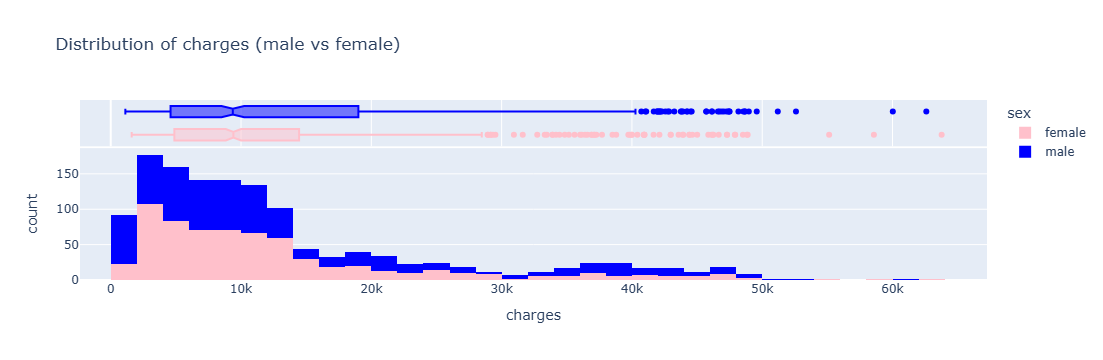

In [77]:
fig = px.histogram(
    medical,
    x="charges",
    marginal="box",
    color="sex",
    color_discrete_sequence=["pink", "blue"],
    title="Distribution of charges (male vs female)"
)

fig.show()

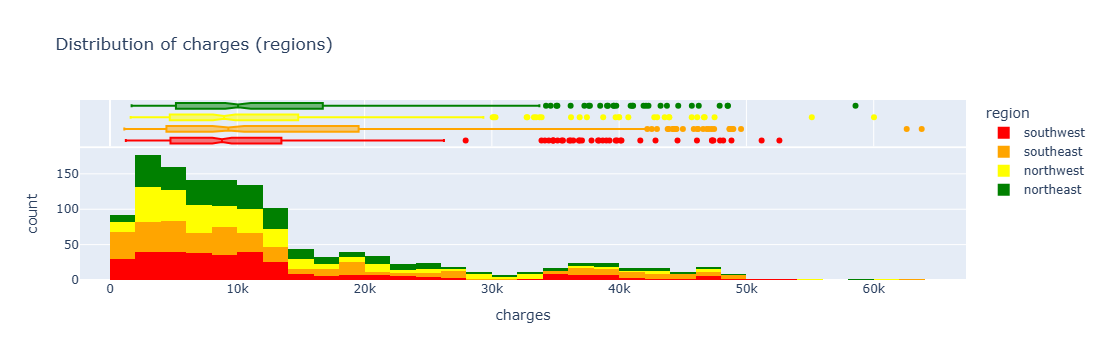

In [78]:
fig = px.histogram(
    medical,
    x="charges",
    marginal="box",
    color="region",
    color_discrete_sequence=["red", "orange", "yellow", "green"],
    title="Distribution of charges (regions)"
)

fig.show()

In [79]:
medical.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [80]:
medical.value_counts("sex")

sex
male      676
female    662
Name: count, dtype: int64

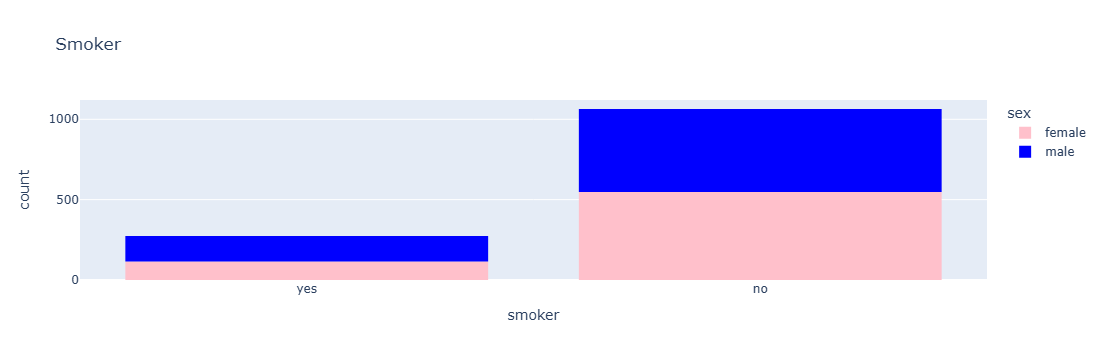

In [81]:
px.histogram(medical, x="smoker", color="sex", color_discrete_sequence=["pink", "blue"], title="Smoker")

The smoker and non smoker distribution between male and female is uniform.It appears that 20% have reported that they smoke

## Age and charges

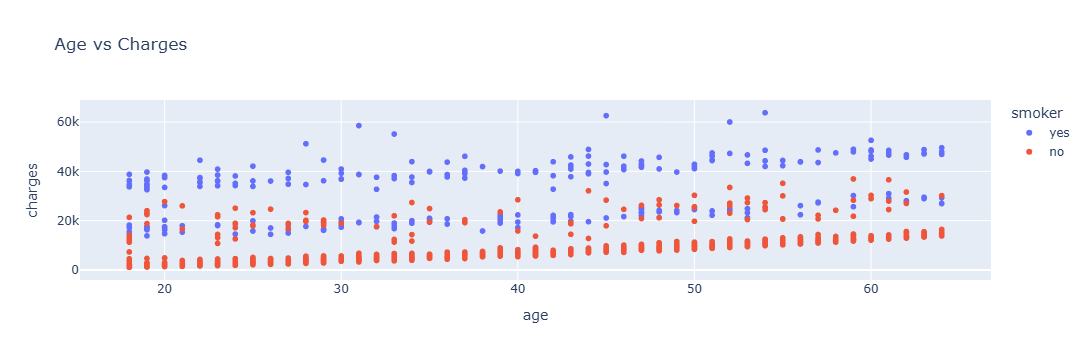

In [82]:
fig = px.scatter(medical, x="age", y="charges", color="smoker", hover_data=["region", "sex"], title="Age vs Charges")
fig.show()

The general trend might be that the charges increase with age, we can observ three clusters: one with only non smokers, another one with smokers and non-smokers and a last with only smmokers. (This representation might confirm the fact that being smoker or not can highly influence the annual insurance charges).

### BMI and Charges

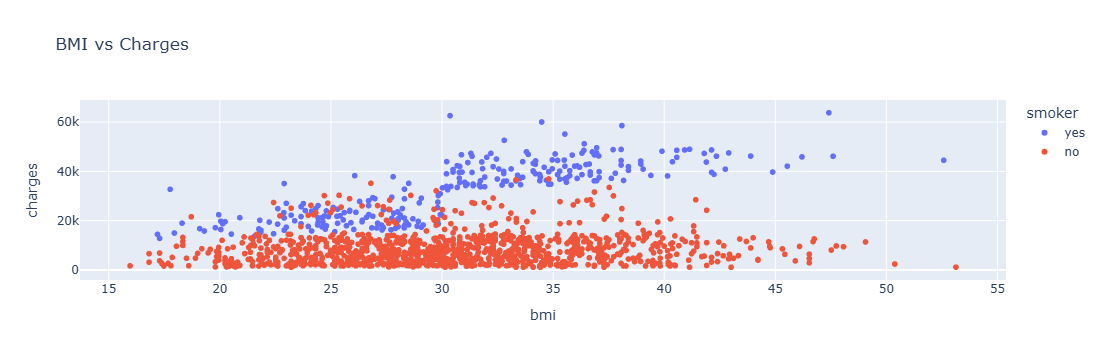

In [83]:
fig = px.scatter(medical, x="bmi", y="charges", color="smoker", hover_data=["age", "sex"], title="BMI vs Charges")
fig.show()

It appears that for non-smoker there's not really any relationship between bmi and charges, but for smokers, we can see charges increasing as well bmi is increasing 

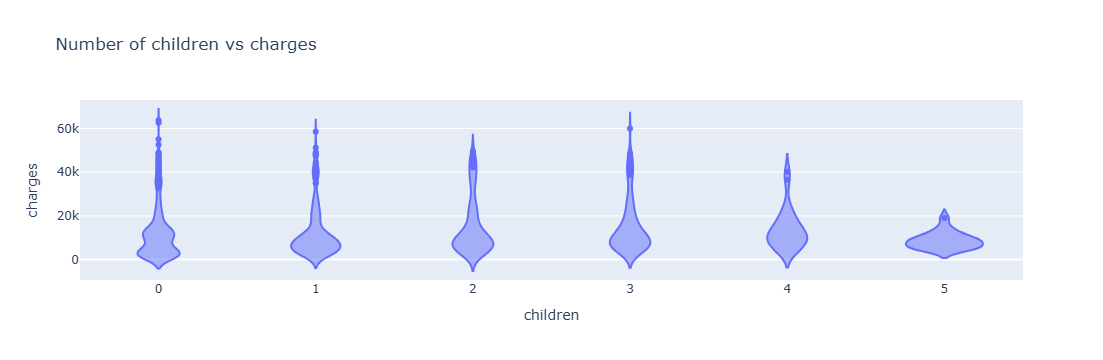

In [84]:
fig = px.violin(medical, x="children", y="charges", title="Number of children vs charges")
fig.show()

The annual insurance charges lower with the number of children

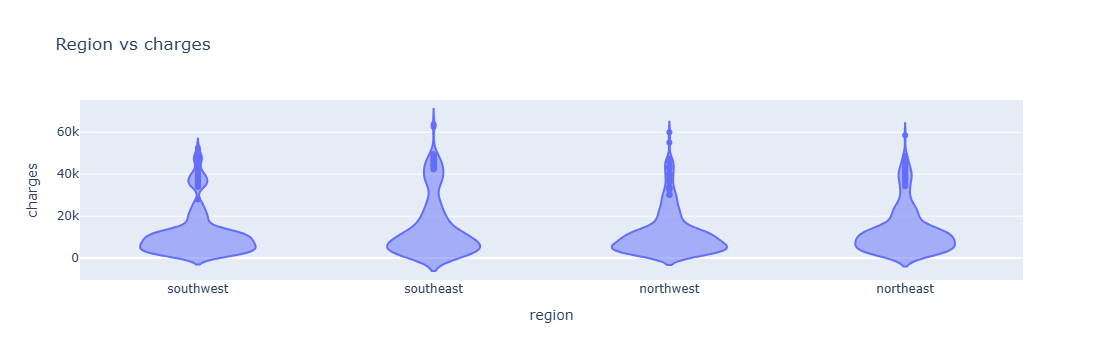

In [85]:
fig = px.violin(medical, x="region", y="charges", title="Region vs charges")
fig.show()

The region vs charges distribution seem uniform, there's no any linearity among charges and region

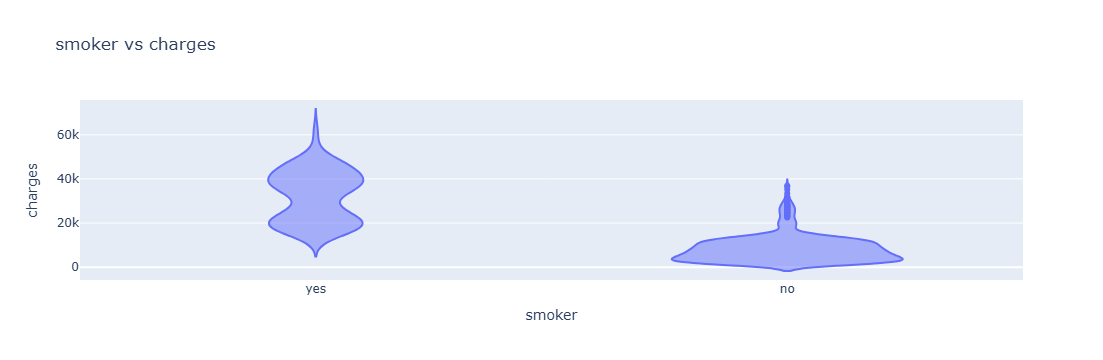

In [86]:
fig = px.violin(medical, x="smoker", y="charges", title="smoker vs charges")
fig.show()

### Correlation

In [87]:
medical["charges"].corr(medical["age"])

np.float64(0.2990081933306478)

In [88]:
medical["charges"].corr(medical["bmi"])

np.float64(0.19834096883362887)

In [89]:
smoker_values ={"yes": 1, "no": 0}
smoker_numeric = medical.smoker.map(smoker_values)
medical.charges.corr(smoker_numeric)

np.float64(0.7872514304984778)

The greater the absolute value, the stronger the relationship. In our case, the highest correlation is among smooker and charges, which means the strongest relationship is between the annual insurance charges and if an individual is a smoker or not.

In [90]:
corr = medical.corr(numeric_only=True)
corr

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

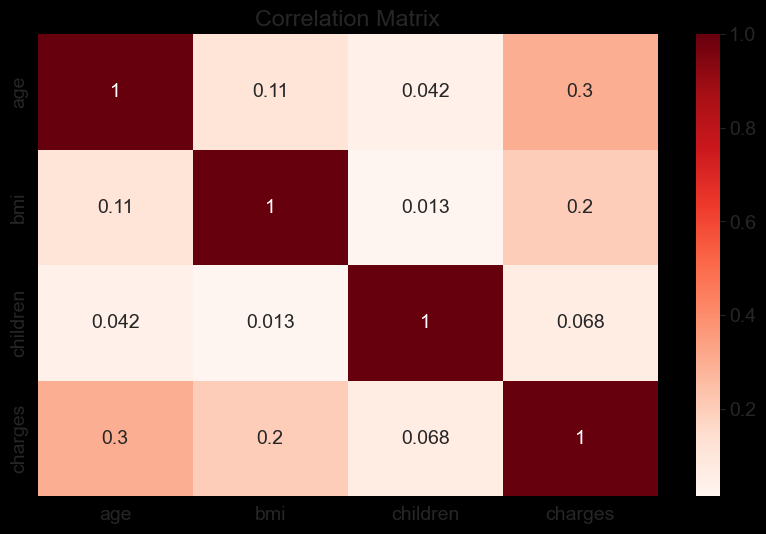

In [91]:
sns.heatmap(corr, cmap="Reds", annot=True)
plt.title("Correlation Matrix")